# 03 - Results Analysis and Evaluation

## 1. Import libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
from pathlib import Path
import yaml
import json

# PyTorch
import torch

# HuggingFace
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress
from tqdm.auto import tqdm

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_colwidth', 100)

print("✓ Libraries imported successfully")

C:\Users\Darjay\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Darjay\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


✓ Libraries imported successfully


In [2]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## 2. Load Configuration and Data

In [4]:
# Load parameters
with open('../params.yaml', 'r') as f:
    params = yaml.safe_load(f)

print("Configuration loaded:")
print(f"  Model: {params['train']['model_name']}")
print(f"  Batch size: {params['train']['batch_size']}")
print(f"  Max length: {params['train']['max_length']}")

Configuration loaded:
  Model: distilbert-base-uncased
  Batch size: 8
  Max length: 96


In [48]:
# Load test data
test_df = pd.read_parquet('../data/raw/imdb_test.parquet')

print(f"\nTest set loaded:")
print(f"  Samples: {len(test_df):,}")
print(f"  Columns: {test_df.columns.tolist()}")

# Display sample
print("\nFirst 5 samples:")
test_df.head()


Test set loaded:
  Samples: 25,000
  Columns: ['text', 'label']

First 5 samples:


,text,label
0,"I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, und...",0
1,"Worth the entertainment value of a rental, especially if you like action movies. This one featur...",0
2,its a totally average film with a few semi-alright action sequences that make the plot seem a li...,0
3,STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday ...,0
4,"First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably wi...",0


In [7]:
# Check label distribution
label_counts = test_df['label'].value_counts()
print("\nTest set label distribution:")
print(f"  Negative (0): {label_counts[0]:,} ({label_counts[0]/len(test_df)*100:.1f}%)")
print(f"  Positive (1): {label_counts[1]:,} ({label_counts[1]/len(test_df)*100:.1f}%)")


Test set label distribution:
  Negative (0): 12,500 (50.0%)
  Positive (1): 12,500 (50.0%)


## 3. Load Trained Model

In [8]:
# Load model and tokenizer
model_dir = Path('../models/trained/distilbert_sentiment')

if not model_dir.exists():
    raise FileNotFoundError(f"Model not found at {model_dir}. Please run notebook 02 first.")

print(f"Loading model from: {model_dir}")

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.eval()
model.to(device)

print("✓ Model and tokenizer loaded")
print(f"  Device: {device}")
print(f"  Vocab size: {len(tokenizer):,}")

Loading model from: ..\models\trained\distilbert_sentiment
✓ Model and tokenizer loaded
  Device: cpu
  Vocab size: 30,522


## 4. Generate Predictions on Test Set

In [9]:
# Prediction function
def predict_batch(texts, model, tokenizer, device, batch_size=16, max_length=128):
    """Generate predictions for a batch of texts"""
    all_probs = []
    all_preds = []
    
    model.eval()
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            
            # Tokenize
            inputs = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=max_length,
                return_tensors='pt'
            )
            
            # Move to device
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Predict
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            
            # Collect results
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of positive class
            all_preds.extend(preds.cpu().numpy())
    
    return np.array(all_preds), np.array(all_probs)

print("✓ Prediction function defined")

✓ Prediction function defined


In [10]:
# Generate predictions
print("Generating predictions on test set...")
print(f"Processing {len(test_df):,} samples...")

texts = test_df['text'].astype(str).tolist()
y_true = test_df['label'].astype(int).values

y_pred, y_proba = predict_batch(
    texts,
    model,
    tokenizer,
    device,
    batch_size=params['train']['batch_size'],
    max_length=params['train']['max_length']
)

print("\n✓ Predictions complete")
print(f"  True labels shape: {y_true.shape}")
print(f"  Predictions shape: {y_pred.shape}")
print(f"  Probabilities shape: {y_proba.shape}")

Generating predictions on test set...
Processing 25,000 samples...

✓ Predictions complete
  True labels shape: (25000,)
  Predictions shape: (25000,)
  Probabilities shape: (25000,)


## 5. Compute Evaluation Metrics

In [32]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_proba)

print("TEST SET EVALUATION METRICS")
print("-" * 80)
print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

TEST SET EVALUATION METRICS
--------------------------------------------------------------------------------

Accuracy:  0.8508 (85.08%)
Precision: 0.8413
Recall:    0.8648
F1 Score:  0.8529
ROC AUC:   0.9325


In [33]:
# Classification report
print("\nDetailed Classification Report:")
print("-" * 80)
print(classification_report(
    y_true, 
    y_pred, 
    target_names=['Negative', 'Positive'],
    digits=4
))


Detailed Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Negative     0.8609    0.8369    0.8487     12500
    Positive     0.8413    0.8648    0.8529     12500

    accuracy                         0.8508     25000
   macro avg     0.8511    0.8508    0.8508     25000
weighted avg     0.8511    0.8508    0.8508     25000



In [13]:
# Save metrics to JSON
metrics = {
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc),
    'test_samples': int(len(test_df))
}

metrics_path = Path('../reports/metrics.json')
metrics_path.parent.mkdir(parents=True, exist_ok=True)

with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"✓ Metrics saved to: {metrics_path}")

✓ Metrics saved to: ..\reports\metrics.json


## 6. Confusion Matrix

In [34]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print("-" * 60)
print(cm)

print("\nBreakdown:")
print(f"  True Negatives (TN):  {cm[0, 0]:,}")
print(f"  False Positives (FP): {cm[0, 1]:,}")
print(f"  False Negatives (FN): {cm[1, 0]:,}")
print(f"  True Positives (TP):  {cm[1, 1]:,}")

print("\nRates:")
print(f"  True Negative Rate:  {cm[0, 0] / (cm[0, 0] + cm[0, 1]):.2%}")
print(f"  True Positive Rate:  {cm[1, 1] / (cm[1, 0] + cm[1, 1]):.2%}")
print(f"  False Positive Rate: {cm[0, 1] / (cm[0, 0] + cm[0, 1]):.2%}")
print(f"  False Negative Rate: {cm[1, 0] / (cm[1, 0] + cm[1, 1]):.2%}")

Confusion Matrix:
------------------------------------------------------------
[[10461  2039]
 [ 1690 10810]]

Breakdown:
  True Negatives (TN):  10,461
  False Positives (FP): 2,039
  False Negatives (FN): 1,690
  True Positives (TP):  10,810

Rates:
  True Negative Rate:  83.69%
  True Positive Rate:  86.48%
  False Positive Rate: 16.31%
  False Negative Rate: 13.52%


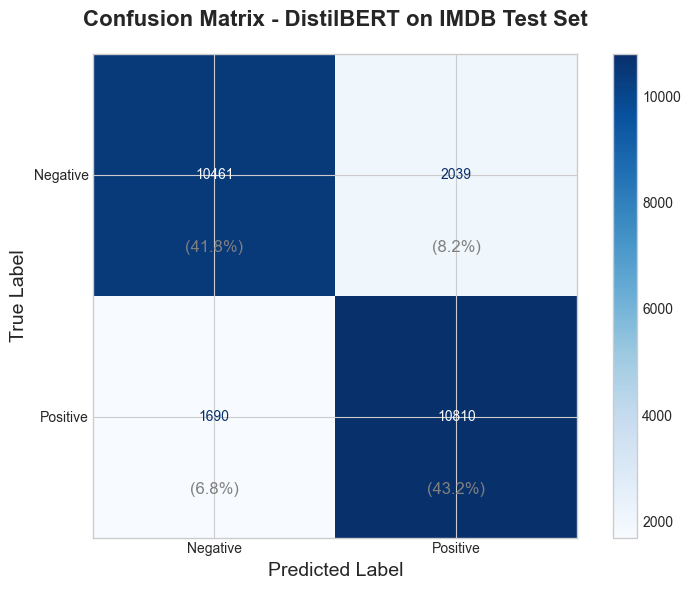

✓ Saved: reports/confusion_matrix.png


In [49]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
)
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=True)

ax.set_title('Confusion Matrix - DistilBERT on IMDB Test Set', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm.sum() * 100
        ax.text(j, i + 0.3, f'({percentage:.1f}%)', 
               ha='center', va='center', fontsize=12, color='gray')

plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: reports/confusion_matrix.png")

## 7. ROC Curve and AUC

In [35]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)

# Find optimal threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("ROC Curve Analysis:")
print("-" * 60)
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"  TPR at optimal: {tpr[optimal_idx]:.4f}")
print(f"  FPR at optimal: {fpr[optimal_idx]:.4f}")

ROC Curve Analysis:
------------------------------------------------------------
ROC AUC Score: 0.9325
Optimal Threshold: 0.5132
  TPR at optimal: 0.8624
  FPR at optimal: 0.1605


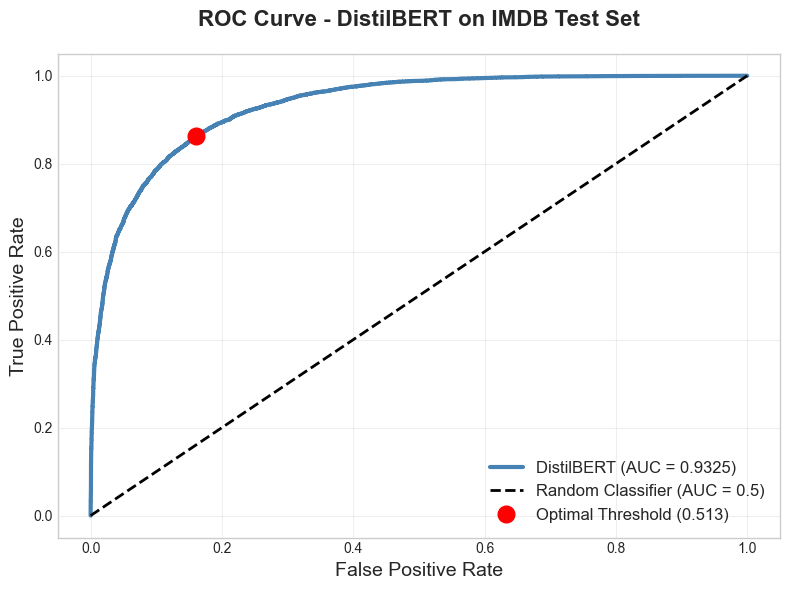

✓ Saved: reports/roc_curve.png


In [50]:
# Visualize ROC curve
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve
ax.plot(fpr, tpr, linewidth=3, label=f'DistilBERT (AUC = {roc_auc:.4f})', color='steelblue')

# Plot random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')

# Mark optimal threshold
ax.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=12, 
        label=f'Optimal Threshold ({optimal_threshold:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('ROC Curve - DistilBERT on IMDB Test Set', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: reports/roc_curve.png")

## 8. Prediction Confidence Analysis

In [36]:
# Analyze prediction confidence
correct_mask = (y_pred == y_true)
incorrect_mask = ~correct_mask

correct_probs = y_proba[correct_mask]
incorrect_probs = y_proba[incorrect_mask]

# Adjust probabilities to be confidence (distance from 0.5)
correct_conf = np.abs(correct_probs - 0.5) + 0.5
incorrect_conf = np.abs(incorrect_probs - 0.5) + 0.5

print("Confidence Analysis:")
print("-" * 60)
print(f"\nCorrect Predictions ({len(correct_probs):,} samples):")
print(f"  Mean confidence: {correct_conf.mean():.4f}")
print(f"  Median confidence: {np.median(correct_conf):.4f}")
print(f"  Min confidence: {correct_conf.min():.4f}")

print(f"\nIncorrect Predictions ({len(incorrect_probs):,} samples):")
print(f"  Mean confidence: {incorrect_conf.mean():.4f}")
print(f"  Median confidence: {np.median(incorrect_conf):.4f}")
print(f"  Min confidence: {incorrect_conf.min():.4f}")

Confidence Analysis:
------------------------------------------------------------

Correct Predictions (21,271 samples):
  Mean confidence: 0.9270
  Median confidence: 0.9766
  Min confidence: 0.5002

Incorrect Predictions (3,729 samples):
  Mean confidence: 0.7887
  Median confidence: 0.8142
  Min confidence: 0.5002


C:\Users\Darjay\AppData\Local\Temp\ipykernel_8864\1715292789.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


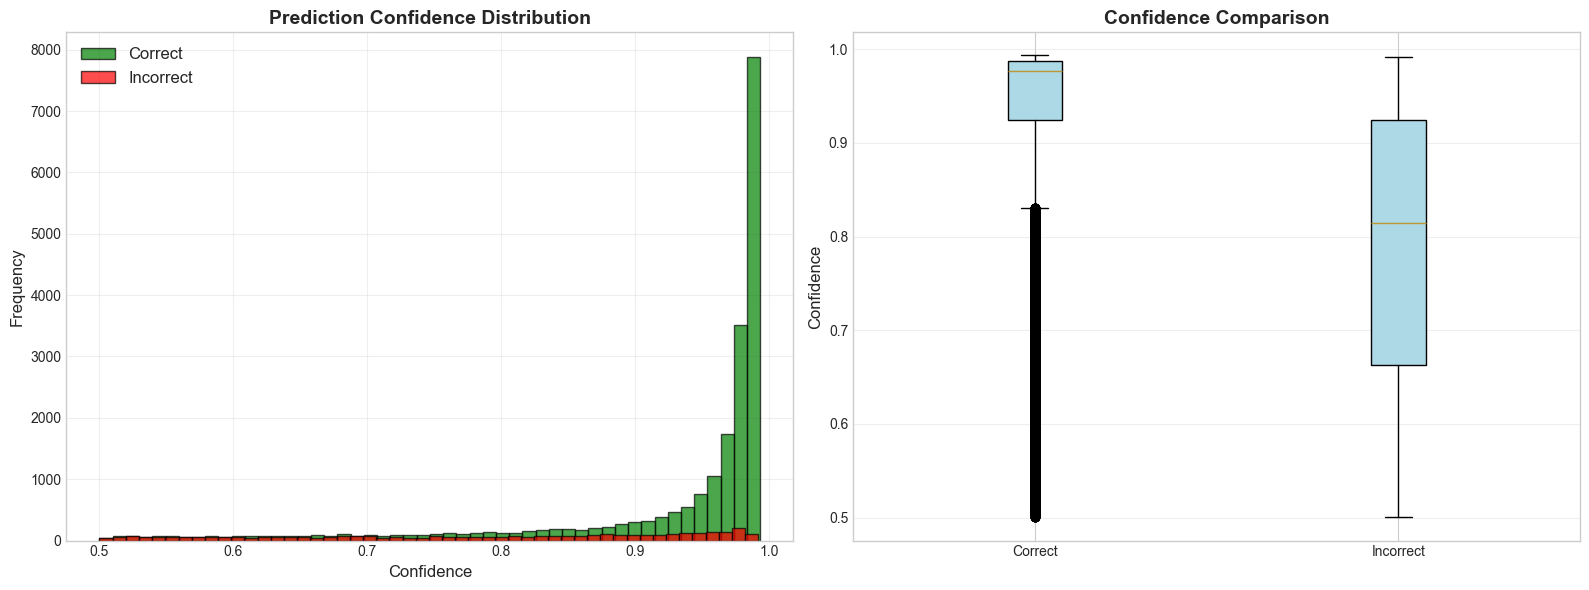

✓ Saved: reports/confidence_analysis.png


In [19]:
# Visualize confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(correct_conf, bins=50, alpha=0.7, label='Correct', color='green', edgecolor='black')
axes[0].hist(incorrect_conf, bins=50, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Confidence', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(
    [correct_conf, incorrect_conf],
    labels=['Correct', 'Incorrect'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
axes[1].set_ylabel('Confidence', fontsize=12)
axes[1].set_title('Confidence Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: reports/confidence_analysis.png")

## 9. Error Analysis

In [37]:
# Create results dataframe
results_df = test_df.copy()
results_df['predicted'] = y_pred
results_df['probability'] = y_proba
results_df['correct'] = correct_mask

# Separate errors
false_positives = results_df[(results_df['label'] == 0) & (results_df['predicted'] == 1)]
false_negatives = results_df[(results_df['label'] == 1) & (results_df['predicted'] == 0)]

print("Error Breakdown:")
print("-" * 60)
print(f"Total errors: {len(results_df[~correct_mask]):,} / {len(results_df):,} ({(~correct_mask).mean()*100:.2f}%)")
print(f"\nFalse Positives: {len(false_positives):,}")
print(f"  (Negative reviews predicted as Positive)")
print(f"\nFalse Negatives: {len(false_negatives):,}")
print(f"  (Positive reviews predicted as Negative)")

Error Breakdown:
------------------------------------------------------------
Total errors: 3,729 / 25,000 (14.92%)

False Positives: 2,039
  (Negative reviews predicted as Positive)

False Negatives: 1,690
  (Positive reviews predicted as Negative)


In [39]:
# Analyze False Positives
print("FALSE POSITIVE EXAMPLES (Negative → Predicted Positive)")
print("=" * 80)

# Sort by confidence (most confident errors)
fp_sorted = false_positives.sort_values('probability', ascending=False)

for i, (idx, row) in enumerate(fp_sorted.head(5).iterrows(), 1):
    print(f"\n[{i}] Confidence: {row['probability']:.2%}")
    print(f"Text: {row['text'][:300]}...")
    print("." * 80)

FALSE POSITIVE EXAMPLES (Negative → Predicted Positive)

[1] Confidence: 98.95%
Text: Earnest effort which achieves some success to adapt the classic Odyssey story to a '30's nostalgia period piece. The adventurers this time are escaped convicts, wandering about the Depression afflicted South bungling their way into trouble.<br /><br />The greatest strength of the film is the wonderf...
................................................................................

[2] Confidence: 98.92%
Text: This is one of the best looking films of the past few years. The fact that it was done on a virtual shoestring ($1.8 million or so they say on the DVD:they infer that they ended up with even less financing) makes it all the more impressive. Not simply the photography, but the design and particularly...
................................................................................

[3] Confidence: 98.90%
Text: This is definitely one of the best Kung fu movies in the history of Cinema. The scre

In [42]:
# Analyze False Negatives
print("FALSE NEGATIVE EXAMPLES (Positive → Predicted Negative)")
print("-" * 80)

# Sort by confidence (most confident errors)
fn_sorted = false_negatives.sort_values('probability', ascending=True)

for i, (idx, row) in enumerate(fn_sorted.head(5).iterrows(), 1):
    print(f"\n[{i}] Confidence: {1 - row['probability']:.2%}")
    print(f"Text: {row['text'][:300]}...")

FALSE NEGATIVE EXAMPLES (Positive → Predicted Negative)
--------------------------------------------------------------------------------

[1] Confidence: 99.18%
Text: I don't know how I would feel if I lived in USA. I would watch some preview scenes, advertisements, I would know, Sidney Pollack directed it, Harrison Ford and Kristin Scott Thomas starring in. I would watch this film as soon as possible without reading any bad review. Would I be disappointment?<br ...

[2] Confidence: 99.14%
Text: I just saw this for the first time in 10 or 15 years...maybe close to 20. In some ways, it was better than I remembered...in other, it was MUCH worse.<br /><br />First of all, there's the music. It's just plain awful. There are only 5 songs in the movie, most of them used more than once. The opening...

[3] Confidence: 99.12%
Text: Miles O'Keeffe once again assumes the role of the mighty Ator in this the first sequel to the original film.<br /><br />What can I say? - This pretty much represents

In [44]:
# Analyze low-confidence correct predictions
print("\n" + "=" * 80)
print("LOW-CONFIDENCE CORRECT PREDICTIONS (Edge Cases)")
print("-" * 80)

correct_df = results_df[correct_mask]

# Find predictions close to 0.5 (uncertain)
uncertain_mask = (correct_df['probability'] > 0.45) & (correct_df['probability'] < 0.55)
uncertain_correct = correct_df[uncertain_mask].copy()

print(f"\nFound {len(uncertain_correct)} uncertain but correct predictions")

if len(uncertain_correct) > 0:
    for i, (idx, row) in enumerate(uncertain_correct.head(3).iterrows(), 1):
        true_sentiment = 'Positive' if row['label'] == 1 else 'Negative'
        print(f"\n[{i}] True: {true_sentiment}, Probability: {row['probability']:.4f}")
        print(f"Text: {row['text'][:300]}...")


LOW-CONFIDENCE CORRECT PREDICTIONS (Edge Cases)
--------------------------------------------------------------------------------

Found 325 uncertain but correct predictions

[1] True: Negative, Probability: 0.4886
Text: The only reason this movie is not given a 1 (awful) vote is that the acting of both Ida Lupino and Robert Ryan is superb. Ida Lupino who is lovely, as usual, becomes increasingly distraught as she tries various means to rid herself of a madman. Robert Ryan is terrifying as the menacing stranger whos...

[2] True: Negative, Probability: 0.4975
Text: I wish I knew what to make of a movie like this. It seems to be divided into two parts -- action sequences and personal dramas ashore. It follows Ashton Kutsher through survival swimmer school, guided by Master Chief Kevin Costner, then to Alaska where a couple of spectacular rescues take place, the...

[3] True: Negative, Probability: 0.4709
Text: It is OK movie if it would be done by high school kids for their friends. It

## 10. Final Summary and Insights

In [46]:
# Comprehensive summary
print("FINAL EVALUATION SUMMARY")
print("-" * 80)

print("\n1. Test Set Performance:")
print(f"   Samples evaluated: {len(test_df):,}")
print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   F1 Score: {f1:.4f}")
print(f"   ROC AUC: {roc_auc:.4f}")

print("\n2. Error Analysis:")
print(f"   Total errors: {(~correct_mask).sum():,} ({(~correct_mask).mean()*100:.2f}%)")
print(f"   False Positives: {len(false_positives):,}")
print(f"   False Negatives: {len(false_negatives):,}")

print("\n3. Confidence:")
print(f"   Mean confidence (correct): {correct_conf.mean():.4f}")
print(f"   Mean confidence (incorrect): {incorrect_conf.mean():.4f}")


FINAL EVALUATION SUMMARY
--------------------------------------------------------------------------------

1. Test Set Performance:
   Samples evaluated: 25,000
   Accuracy: 0.8508 (85.08%)
   F1 Score: 0.8529
   ROC AUC: 0.9325

2. Error Analysis:
   Total errors: 3,729 (14.92%)
   False Positives: 2,039
   False Negatives: 1,690

3. Confidence:
   Mean confidence (correct): 0.9270
   Mean confidence (incorrect): 0.7887
